In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
bee_data = pd.read_csv("../data/bee_data.csv")

print(bee_data.head()) # Print top 5 lines
print(bee_data.shape) # Print "shape" features, # of rows & # of columns

          file     date   time        location  zip code subspecies  \
0  041_066.png  8/28/18  16:07  Alvin, TX, USA     77511         -1   
1  041_072.png  8/28/18  16:07  Alvin, TX, USA     77511         -1   
2  041_073.png  8/28/18  16:07  Alvin, TX, USA     77511         -1   
3  041_067.png  8/28/18  16:07  Alvin, TX, USA     77511         -1   
4  041_059.png  8/28/18  16:07  Alvin, TX, USA     77511         -1   

              health  pollen_carrying   caste  
0  hive being robbed            False  worker  
1  hive being robbed            False  worker  
2  hive being robbed            False  worker  
3  hive being robbed            False  worker  
4  hive being robbed            False  worker  
(5172, 9)


In [ ]:
# Data Exploration

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

# Simple shape
print(f"\nDataset shape: {bee_data.shape}")
print(f"Total records: {bee_data.shape[0]}") # print dimension x
print(f"Total features: {bee_data.shape[1]}") # print dimension y

# Info about the columns, types, numbers
print("\n" + "=" * 60)
print("COLUMN INFORMATION")
print("=" * 60)
print(bee_data.info())

# Describe statistics
print("\n" + "=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)
print(bee_data.describe(include='all'))

# Check for missing values
print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)

missing = bee_data.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values!")

# Unique values
print("\n" + "=" * 60)
print("UNIQUE VALUES IN EACH COLUMN")
print("=" * 60)

for col in bee_data.columns:
    unique_count = bee_data[col].nunique()
    print(f"{col}: {unique_count} unique values")

    if unique_count <= 10:
        print(f"  Values: {bee_data[col].unique()}")
        # Only print if it makes sense, don't overload screen

###############
# Modify -1 values in subspecies, even if we don't do anything with it. Basic data engineering best practices
###############

DATASET OVERVIEW

Dataset shape: (5172, 9)
Total records: 5172
Total features: 9

COLUMN INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5172 entries, 0 to 5171
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   file             5172 non-null   object
 1   date             5172 non-null   object
 2   time             5172 non-null   object
 3   location         5172 non-null   object
 4   zip code         5172 non-null   int64 
 5   subspecies       5172 non-null   object
 6   health           5172 non-null   object
 7   pollen_carrying  5172 non-null   bool  
 8   caste            5172 non-null   object
dtypes: bool(1), int64(1), object(7)
memory usage: 328.4+ KB
None

STATISTICAL SUMMARY
               file     date   time           location      zip code  \
count          5172     5172   5172               5172   5172.000000   
unique         5172       16     35                  8           Na

In [ ]:
# Data Cleaning + Preparation

print("=" * 60)
print("DATA CLEANING")
print("=" * 60)

# Check for duplicate rows
duplicates = bee_data.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")
if duplicates > 0:
    bee_data = bee_data.drop_duplicates()
    print(f"Dropped duplicates. New shape: {bee_data.shape}")

# 2 steps for handleing the subspecies column (-1 indicates unknown)
print(f"\nSubspecies value counts:")
print(bee_data['subspecies'].value_counts())

# Step 1: Check which rows have subspecies equal to -1
unknown_mask = bee_data['subspecies'] == -1

# Step 2: Count how many TRUE values there are
subspecies_missing = unknown_mask.sum()

print(f"Missing subspecies (coded as -1): {subspecies_missing}")

# Examine other categorical columns
print("\nCaste value counts:")
print(bee_data['caste'].value_counts())

print("\nHealth value counts:")
print(bee_data['health'].value_counts())

print("\nPollen carrying value counts:")
print(bee_data['pollen_carrying'].value_counts())

# Check zip code distribution
print(f"\nZip code distribution: {bee_data['zip code'].nunique()} unique values")
print(bee_data['zip code'].value_counts().head(10))

# Handle potential data quality issues
print("\n" + "=" * 60)
print("DATA TYPE CONVERSIONS")
print("=" * 60)

# .csv has FALSE and TRUE, but these are not proper boolean types
# Ensure boolean column is proper type
bee_data['pollen_carrying'] = bee_data['pollen_carrying'].astype(str).str.lower() == 'true'
print("Converted pollen_carrying to boolean type")

print(f"\nFinal dataset shape: {bee_data.shape}")
print(bee_data.head())

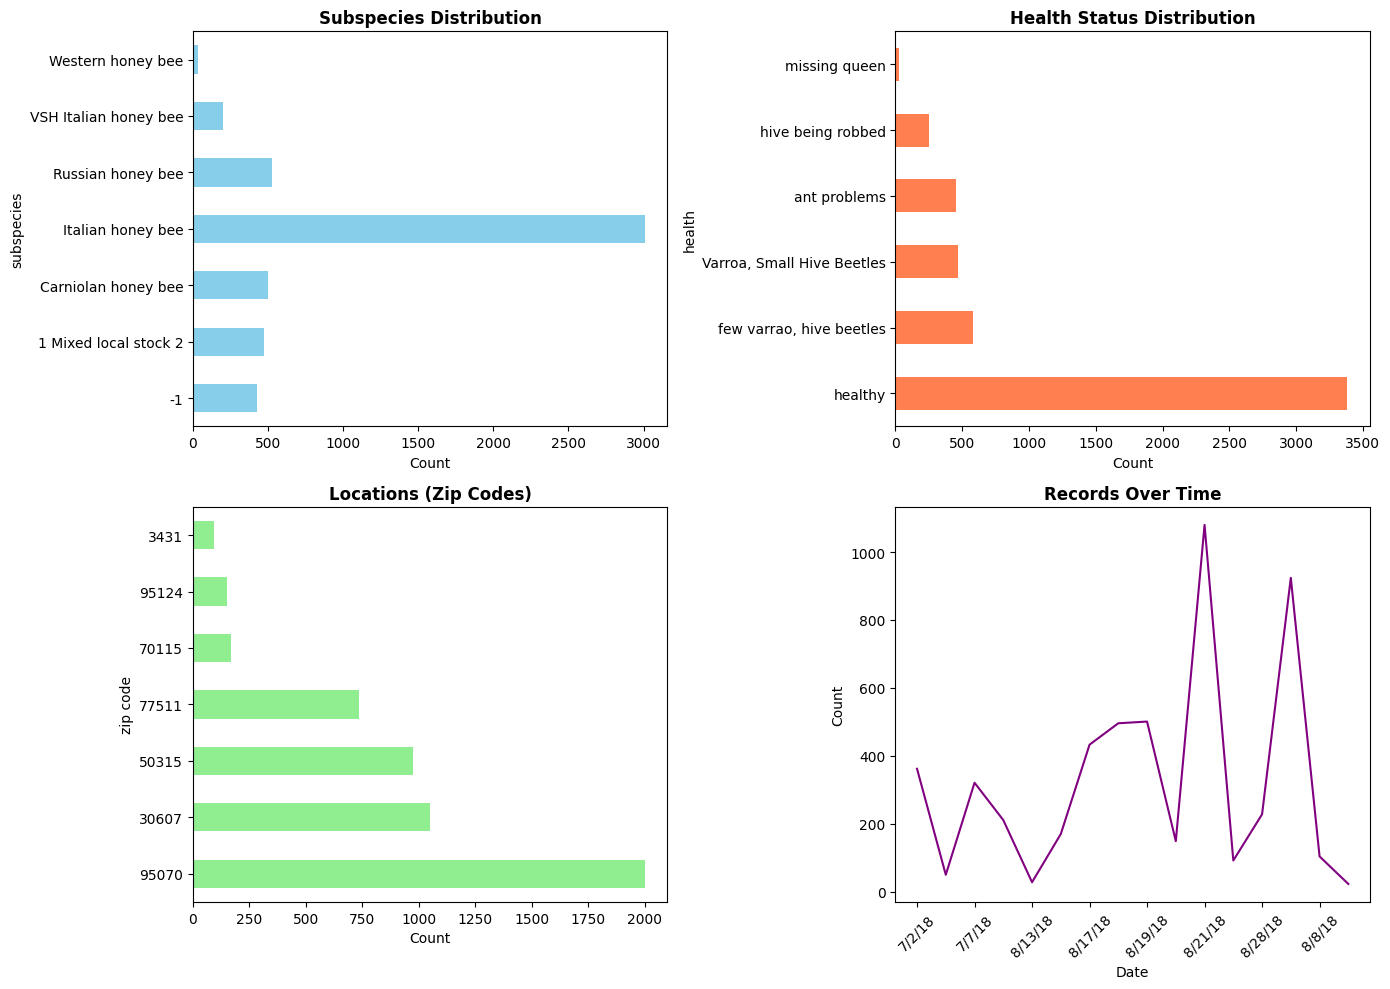

In [ ]:
# Exploratory visualization, useful graphs

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Subspecies distribution
bee_data['subspecies'].value_counts().sort_index().plot(kind='barh', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Subspecies Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Count')

# Plot 2: Health distribution
bee_data['health'].value_counts().plot(kind='barh', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Health Status Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Count')

# Plot 3: Location Distribution
bee_data['zip code'].value_counts().head(10).plot(kind='barh', ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Locations (Zip Codes)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Count')

# Plot 4: Records over time
bee_data['date'].value_counts().sort_index().plot(kind='line', ax=axes[1, 1], color='purple')
axes[1, 1].set_title('Records Over Time', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Count')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#############
# Do something about the heavy class imbalance, and also say in project data preprocessing part
#############
